In [2]:
from __future__ import annotations

from typing import Dict, List, Optional, Sequence, Tuple, Set

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm


NATURE_FONT = {
    "family": "sans-serif",
    "sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
}

CANCER_COLORS = {
    "ccRCC": "#4C72B0",
    "Melanoma": "#DD8452",
    "NSCLC": "#55A868",
}

STABILITY_PLOT_COLORS = {
    "heatmap_bg": "#f7f7f7",
    "missing_edge": "#BDBDBD",
    "missing_face": "#FFFFFF",
}

# Agreement palette (Okabe–Ito-ish, colorblind friendly)
AGREE_DISAGREE_COLORS = {
    "agree": "#0072B2",      # blue
    "disagree": "#D55E00",   # vermillion/orange
    "neutral": "#E6E6E6",    # light gray
}

# Origin direction palette (distinct from agreement)
ORIGIN_DIR_COLORS = {
    "up": "#7B3294",       # purple
    "down": "#008837",     # green/teal
    "neutral": "#E6E6E6",  # gray
}


def _set_nature_rcparams(fontsize: int = 11) -> None:
    """
    Apply Nature-like matplotlib rcParams (Helvetica/Arial and clean axes).

    Args:
        fontsize (int): Base font size for the figure.

    Raises:
        ValueError: If fontsize is not positive.
    """
    if fontsize <= 0:
        raise ValueError("fontsize must be a positive integer.")

    plt.rcParams.update(
        {
            "font.size": fontsize,
            "font.family": NATURE_FONT["family"],
            "font.sans-serif": NATURE_FONT["sans-serif"],
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "axes.titlesize": fontsize + 1,
            "axes.labelsize": fontsize,
            "xtick.labelsize": fontsize - 1,
            "ytick.labelsize": fontsize - 1,
            "legend.fontsize": fontsize - 1,
        }
    )


def _shorten_hallmark_term(term: str) -> str:
    """
    Convert MSigDB Hallmark term into a shorter pathway label for y-axis.

    Args:
        term (str): Raw Hallmark term.

    Returns:
        str: Shortened label.

    Raises:
        ValueError: If term is empty.
    """
    if term is None or str(term).strip() == "":
        raise ValueError("term must be a non-empty string.")

    t = str(term).strip().upper()
    if t.startswith("HALLMARK_"):
        t = t.replace("HALLMARK_", "", 1)

    mapping = {
        "INTERFERON_ALPHA_RESPONSE": r"IFN$\alpha$ response",
        "INTERFERON_GAMMA_RESPONSE": r"IFN$\gamma$ response",
        "IL6_JAK_STAT3_SIGNALING": "IL6–JAK–STAT3",
        "INFLAMMATORY_RESPONSE": "Inflammatory",
        "TGF_BETA_SIGNALING": r"TGF-$\beta$",
        "DNA_REPAIR": "DNA repair",
        "ALLOGRAFT_REJECTION": "Allograft rejection",
        "COMPLEMENT": "Complement",
        "EPITHELIAL_MESENCHYMAL_TRANSITION": "EMT",
        "WNT_BETA_CATENIN_SIGNALING": r"WNT/$\beta$-catenin",
    }
    return mapping.get(t, t.replace("_", " ").title())


def build_origin_nes_sign_vector(
    cancer_nes: Dict[str, List[List[float]]],
    origin_key: str,
    terms_order: Sequence[str],
    sign_eps: float = 1e-8,
) -> pd.Series:
    """
    Build a vector indicating Origin NES direction per pathway.

    Args:
        cancer_nes (Dict[str, List[List[float]]]): Mapping method -> list of [Term, NES].
        origin_key (str): Key for Origin method.
        terms_order (Sequence[str]): Global term order.
        sign_eps (float): Threshold to treat NES close to 0 as neutral.

    Returns:
        pd.Series: Indexed by shortened pathway names, values in {-1, 0, 1, NaN}.

    Raises:
        ValueError: If origin_key is missing.
        ValueError: If terms_order is empty.
    """
    if origin_key not in cancer_nes:
        raise ValueError(f"origin_key '{origin_key}' not found in cancer_nes keys: {sorted(cancer_nes.keys())}")
    if len(list(terms_order)) == 0:
        raise ValueError("terms_order must be provided and non-empty.")

    df = pd.DataFrame(cancer_nes[origin_key], columns=["Term", "NES"])
    df["Term"] = df["Term"].astype(str)
    df["NES"] = pd.to_numeric(df["NES"], errors="coerce")
    df = df.dropna(subset=["Term", "NES"])
    s = df.set_index("Term")["NES"]

    out = []
    for t in list(terms_order):
        if t not in s.index:
            out.append(np.nan)
            continue
        x = float(s.loc[t])
        if not np.isfinite(x) or abs(x) <= sign_eps:
            out.append(0.0)
        else:
            out.append(1.0 if x > 0 else -1.0)

    idx = [_shorten_hallmark_term(t) for t in list(terms_order)]
    return pd.Series(out, index=idx, name=origin_key)


def build_nes_direction_agreement_matrix(
    cancer_nes: Dict[str, List[List[float]]],
    origin_key: str = "Original Direction",
    terms_order: Sequence[str] = (),
    methods_order: Optional[Sequence[str]] = None,
    sign_eps: float = 1e-8,
) -> pd.DataFrame:
    """
    Build a pathway x method matrix encoding direction agreement of NES vs Origin.

    Encoding:
        1  -> agreement (same sign)
        0  -> disagreement (opposite sign)
       -1  -> neutral (one is ~0)
        NaN -> missing term for that method (or missing in Origin)

    Args:
        cancer_nes (Dict[str, List[List[float]]]): Mapping method -> list of [Term, NES].
        origin_key (str): Key for the Origin method.
        terms_order (Sequence[str]): Global term order (shared across cancers).
        methods_order (Optional[Sequence[str]]): Optional ordering of methods (columns).
        sign_eps (float): Threshold to treat NES close to 0 as neutral.

    Returns:
        pd.DataFrame: Matrix indexed by shortened pathway names, columns by methods.

    Raises:
        ValueError: If origin_key is missing.
        ValueError: If terms_order is empty.
        ValueError: If sign_eps is negative.
    """
    if origin_key not in cancer_nes:
        raise ValueError(f"origin_key '{origin_key}' not found in cancer_nes keys: {sorted(cancer_nes.keys())}")
    if len(list(terms_order)) == 0:
        raise ValueError("terms_order must be provided and non-empty.")
    if sign_eps < 0:
        raise ValueError("sign_eps must be >= 0.")

    method_to_series: Dict[str, pd.Series] = {}
    for method, rows in cancer_nes.items():
        df = pd.DataFrame(rows, columns=["Term", "NES"])
        df["Term"] = df["Term"].astype(str)
        df["NES"] = pd.to_numeric(df["NES"], errors="coerce")
        df = df.dropna(subset=["Term", "NES"])
        method_to_series[str(method)] = df.set_index("Term")["NES"]

    origin_series = method_to_series[origin_key]
    methods = list(cancer_nes.keys()) if methods_order is None else list(methods_order)

    terms = list(terms_order)
    mat_raw = pd.DataFrame(index=terms, columns=methods, dtype=float)

    def _sign(x: float) -> int:
        if not np.isfinite(x):
            return 0
        if abs(x) <= sign_eps:
            return 0
        return 1 if x > 0 else -1

    for term in terms:
        if term not in origin_series.index:
            continue

        s0 = _sign(float(origin_series.loc[term]))

        for m in methods:
            s_m = method_to_series.get(m, pd.Series(dtype=float))
            if term not in s_m.index:
                continue
            sm = _sign(float(s_m.loc[term]))

            if s0 == 0 or sm == 0:
                mat_raw.loc[term, m] = -1.0
            else:
                mat_raw.loc[term, m] = 1.0 if (s0 == sm) else 0.0

    mat_raw.index = [_shorten_hallmark_term(t) for t in mat_raw.index]
    return mat_raw


def _paint_origin_column_with_direction(
    ax: plt.Axes,
    mat: pd.DataFrame,
    origin_dir: pd.Series,
    origin_col: str,
    missing_hatch: str,
    edge_lw: float,
) -> None:
    """
    Paint the Origin column cells using NES direction colors and draw a thicker border.

    Args:
        ax (plt.Axes): Heatmap axis.
        mat (pd.DataFrame): Full matrix already drawn as a heatmap.
        origin_dir (pd.Series): Origin NES sign vector indexed by mat.index (values -1/0/1/NaN).
        origin_col (str): Column name for Origin.
        missing_hatch (str): Hatch pattern for missing.
        edge_lw (float): Border line width for the Origin column.
    """
    if origin_col not in mat.columns:
        return

    j0 = list(mat.columns).index(origin_col)
    n_rows = mat.shape[0]

    # Overlay colored rectangles cell-by-cell for Origin column
    for i, pathway in enumerate(mat.index):
        v = origin_dir.get(pathway, np.nan)
        if pd.isna(v):
            # leave as-is (missing will be hatched by global hatch overlay)
            continue
        if v > 0:
            fc = ORIGIN_DIR_COLORS["up"]
        elif v < 0:
            fc = ORIGIN_DIR_COLORS["down"]
        else:
            fc = ORIGIN_DIR_COLORS["neutral"]

        rect = mpatches.Rectangle(
            (j0, i),
            1.0,
            1.0,
            facecolor=fc,
            edgecolor="lightgray",
            linewidth=0.5,
            zorder=15,
        )
        ax.add_patch(rect)

    # Thick border around the Origin column
    border = mpatches.Rectangle(
        (j0, 0),
        1.0,
        float(n_rows),
        fill=False,
        edgecolor="black",
        linewidth=edge_lw,
        zorder=20,
    )
    ax.add_patch(border)


def _overlay_hatched_missing_cells(ax: plt.Axes, mat: pd.DataFrame, hatch: str) -> None:
    """
    Overlay hatched rectangles on NaN cells in the matrix.

    Args:
        ax (plt.Axes): Axis containing the heatmap.
        mat (pd.DataFrame): Heatmap matrix (NaNs indicate missing cells).
        hatch (str): Matplotlib hatch pattern.
    """
    nan_mask = mat.isna().to_numpy()
    nrows, ncols = nan_mask.shape

    for i in range(nrows):
        for j in range(ncols):
            if not nan_mask[i, j]:
                continue
            rect = mpatches.Rectangle(
                (j, i),
                1.0,
                1.0,
                facecolor=STABILITY_PLOT_COLORS["missing_face"],
                edgecolor=STABILITY_PLOT_COLORS["missing_edge"],
                hatch=hatch,
                linewidth=0.6,
                fill=True,
                zorder=30,
            )
            ax.add_patch(rect)


def plot_nes_direction_agreement_heatmap_grid(
    nes_dict: Dict[str, Dict[str, List[List[float]]]],
    cancers_order: Sequence[str] = ("ccRCC", "Melanoma", "NSCLC"),
    origin_key: str = "Original Direction",
    terms_order: Sequence[str] = (),
    methods_order: Optional[Sequence[str]] = None,
    highlighted_pathways: Optional[Sequence[str]] = None,
    sign_eps: float = 1e-8,
    figsize: Tuple[int, int] = (8, 18),  # swap width/height cho vertical layout
    fontsize: int = 11,
    hatch_missing: bool = True,
    missing_hatch: str = "///",
    origin_edge_lw: float = 2.6,
    legend_bbox_to_anchor: Tuple[float, float] = (1.02, 1.0),
    legend_right_margin: float = 0.975,
    show: bool = True,
) -> Tuple[plt.Figure, np.ndarray, Dict[str, pd.DataFrame]]:

    cancers_order = list(cancers_order)
    for c in cancers_order:
        if c not in nes_dict:
            raise ValueError(f"Cancer '{c}' missing from nes_dict keys: {sorted(nes_dict.keys())}")

    if len(list(terms_order)) == 0:
        raise ValueError("terms_order must be provided and non-empty.")

    if methods_order is not None and origin_key not in list(methods_order):
        raise ValueError("methods_order must include origin_key.")

    highlighted_set: Set[str] = set([str(x) for x in highlighted_pathways]) if highlighted_pathways else set()

    _set_nature_rcparams(fontsize=fontsize)
    sns.set(style="white", rc={"axes.facecolor": STABILITY_PLOT_COLORS["heatmap_bg"]})

    # Agreement colormap: -1 neutral, 0 disagree, 1 agree
    agree_cmap = ListedColormap(
        [AGREE_DISAGREE_COLORS["neutral"], AGREE_DISAGREE_COLORS["disagree"], AGREE_DISAGREE_COLORS["agree"]]
    )
    agree_norm = BoundaryNorm(boundaries=[-1.5, -0.5, 0.5, 1.5], ncolors=agree_cmap.N)

    # 1 column, N rows
    fig, axes = plt.subplots(len(cancers_order), 1, figsize=figsize)
    if len(cancers_order) == 1:
        axes = np.array([axes])

    matrices_by_cancer: Dict[str, pd.DataFrame] = {}

    for ax, cancer in zip(axes, cancers_order):
        cols = list(nes_dict[cancer].keys()) if methods_order is None else list(methods_order)

        # Agreement matrix
        agree_mat = build_nes_direction_agreement_matrix(
            cancer_nes=nes_dict[cancer],
            origin_key=origin_key,
            terms_order=terms_order,
            methods_order=cols,
            sign_eps=sign_eps,
        )
        agree_mat = agree_mat.reindex(columns=cols)

        # Origin direction vector
        origin_dir = build_origin_nes_sign_vector(
            cancer_nes=nes_dict[cancer],
            origin_key=origin_key,
            terms_order=terms_order,
            sign_eps=sign_eps,
        ).reindex(agree_mat.index)

        matrices_by_cancer[cancer] = agree_mat

        # Draw base heatmap
        mask = agree_mat.isna()
        sns.heatmap(
            agree_mat,
            ax=ax,
            cmap=agree_cmap,
            norm=agree_norm,
            mask=mask if hatch_missing else None,
            linewidths=0.5,
            linecolor="lightgray",
            cbar=False,
            square=False,
        )

        # Repaint Origin column
        _paint_origin_column_with_direction(
            ax=ax,
            mat=agree_mat,
            origin_dir=origin_dir,
            origin_col=origin_key,
            missing_hatch=missing_hatch,
            edge_lw=origin_edge_lw,
        )

        # Hatch missing
        if hatch_missing:
            _overlay_hatched_missing_cells(ax=ax, mat=agree_mat, hatch=missing_hatch)

        ax.set_title(cancer, fontsize=fontsize + 1, fontweight="bold", pad=10)
        cancer_color = CANCER_COLORS.get(cancer, "#333333")
        ax.plot([0.02, 0.98], [1.02, 1.02], transform=ax.transAxes, color=cancer_color, lw=4, clip_on=False)

        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)

        for t in ax.get_xticklabels():
            t.set_horizontalalignment("right")
            t.set_rotation_mode("anchor")

        for tick in ax.get_yticklabels():
            if tick.get_text() in highlighted_set:
                tick.set_fontweight("bold")
                tick.set_color("red")

    # Legend
    legend_handles = [
        mpatches.Patch(facecolor=ORIGIN_DIR_COLORS["up"], edgecolor="none", label=f"{origin_key}: NES > 0"),
        mpatches.Patch(facecolor=ORIGIN_DIR_COLORS["down"], edgecolor="none", label=f"{origin_key}: NES < 0"),
        mpatches.Patch(facecolor=ORIGIN_DIR_COLORS["neutral"], edgecolor="none", label=f"{origin_key}: NES≈0"),
        mpatches.Patch(facecolor=AGREE_DISAGREE_COLORS["agree"], edgecolor="none", label="Agreement: Agree"),
        mpatches.Patch(facecolor=AGREE_DISAGREE_COLORS["disagree"], edgecolor="none", label="Agreement: Disagree"),
        mpatches.Patch(facecolor=AGREE_DISAGREE_COLORS["neutral"], edgecolor="none", label="Agreement: Neutral"),
        mpatches.Patch(
            facecolor=STABILITY_PLOT_COLORS["missing_face"],
            edgecolor=STABILITY_PLOT_COLORS["missing_edge"],
            hatch=missing_hatch,
            label="Missing",
        ),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=legend_bbox_to_anchor,
        frameon=False,
        title="Legend",
        fontsize=fontsize - 1,
        title_fontsize=fontsize,
        borderaxespad=0.0,
        handletextpad=0.6,
    )

    plt.tight_layout(rect=[0, 0, legend_right_margin, 1])

    if show:
        plt.show()

    return fig, axes, matrices_by_cancer


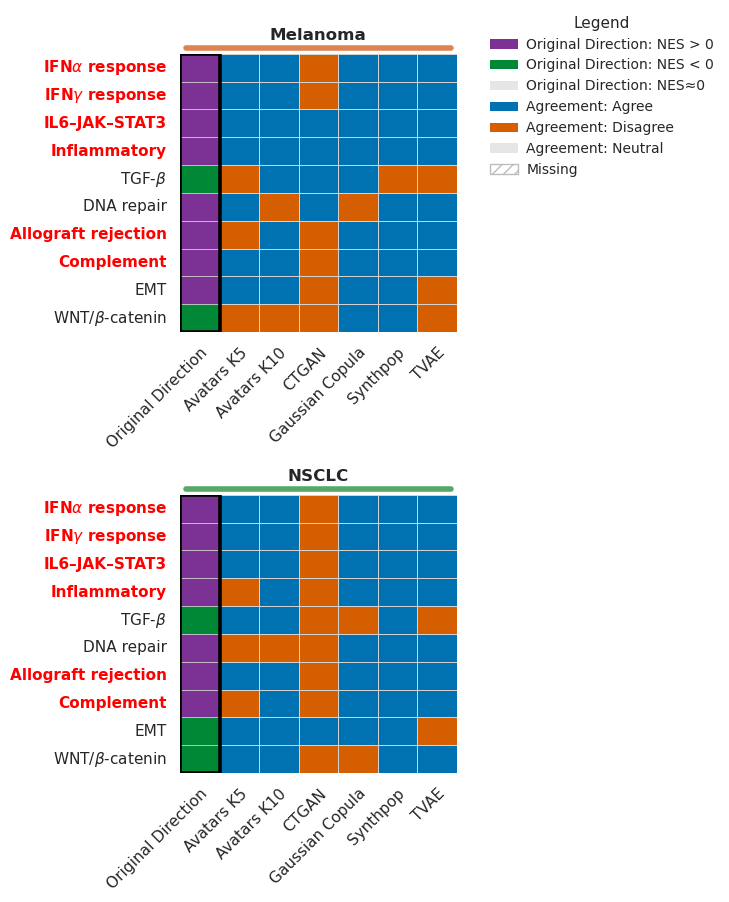

In [4]:
import pandas as pd
import numpy as np 
seeds = [0,1,2,3,42]
# seeds = ['presentive']
for seed in seeds:
    NES_dict = {}
    terms = ['HALLMARK_INTERFERON_ALPHA_RESPONSE','HALLMARK_INTERFERON_GAMMA_RESPONSE',
            'HALLMARK_IL6_JAK_STAT3_SIGNALING','HALLMARK_INFLAMMATORY_RESPONSE',
            'HALLMARK_TGF_BETA_SIGNALING','HALLMARK_DNA_REPAIR','HALLMARK_ALLOGRAFT_REJECTION',
            'HALLMARK_COMPLEMENT', 'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION',
            'HALLMARK_WNT_BETA_CATENIN_SIGNALING']
    
    #Melanoma 
    Melanoma_nes = {}
    DataSeed_Melanoma ={
        'avatarsk5': 2,
        'avatarsk10': 0,
        'ctgan': 42,
       'gaussiancopula': 42,
        'synthpop': 1,
        'tvae': 1
    }
    
    
    # DataSeed_Melanoma ={
    #     'avatarsk5': seed,
    #     'avatarsk10': seed,
    #     'ctgan': seed,
    #    'gaussiancopula': seed,
    #     'synthpop': seed,
    #     'tvae': seed
    # }
    
    names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']
    gsea_res_or = pd.read_csv(f'../Melanoma/NarrowUtility/GSEA/CRPR_PD/Seed_42/GSEA_Origin.csv')
    gsea_nes_or= gsea_res_or[gsea_res_or['Term'].isin(terms)][['Term','NES']].values.tolist()
    Melanoma_nes['Original Direction'] = gsea_nes_or
    for i, tool in enumerate(names): 
        dataset = list(DataSeed_Melanoma.keys())[i]
        seed = list(DataSeed_Melanoma.values())[i]
        gsea_res = pd.read_csv(f'../Melanoma/NarrowUtility/GSEA/CRPR_PD/Seed_{seed}/GSEA_{dataset}_{seed}.csv')
        gsea_nes_syn= gsea_res[gsea_res['Term'].isin(terms)][['Term','NES']].values.tolist()
        Melanoma_nes[tool] = gsea_nes_syn
    
    #NSCLC 
    NSCLC_nes = {}
    DataSeed_NSCLC ={
        'avatarsk5': 1,
        'avatarsk10': 42,
        'ctgan': 0,
       'gaussiancopula': 0,
        'synthpop': 3,
        'tvae': 2
    }
    
    # DataSeed_NSCLC ={
    #     'avatarsk5': seed,
    #     'avatarsk10': seed,
    #     'ctgan': seed,
    #    'gaussiancopula': seed,
    #     'synthpop': seed,
    #     'tvae': seed
    # }
    gsea_res_or = pd.read_csv(f'../NSCLC/NarrowUtility/GSEA/CRPR_PD/Seed_42/GSEA_Origin.csv')
    gsea_nes_or= gsea_res_or[gsea_res_or['Term'].isin(terms)][['Term','NES']].values.tolist()
    NSCLC_nes['Original Direction'] = gsea_nes_or
    
    for i, tool in enumerate(names): 
        dataset = list(DataSeed_NSCLC.keys())[i]
        seed = list(DataSeed_NSCLC.values())[i]
        gsea_res = pd.read_csv(f'../NSCLC/NarrowUtility/GSEA/CRPR_PD/Seed_{seed}/GSEA_{dataset}_{seed}.csv')
        gsea_nes_syn= gsea_res[gsea_res['Term'].isin(terms)][['Term','NES']].values.tolist()
        NSCLC_nes[tool] = gsea_nes_syn
    
    #Overall
    NES_dict = {'Melanoma': Melanoma_nes, 'NSCLC':NSCLC_nes}

    methods_order = ["Original Direction", "Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"]

    highlighted = [
        r"IFN$\gamma$ response",
        r"IFN$\alpha$ response",
        "IL6–JAK–STAT3",
        "Inflammatory",
        r"Allograft rejection",
         "Complement"
    ]
    fig, axes, mats = plot_nes_direction_agreement_heatmap_grid(
        nes_dict=NES_dict,
        cancers_order=["Melanoma", "NSCLC"],
        origin_key="Original Direction",
        terms_order=terms,              # your 10 hallmark terms list
        methods_order=methods_order,
        highlighted_pathways=highlighted,
        figsize=(5,9),
        fontsize=11,
        legend_bbox_to_anchor=(0.985, 1.0),  # closer
        legend_right_margin=0.965,           # less whitespace
    )
    fig.savefig(f"HeatmapArgreement/Seed_{seed}.pdf", dpi=300, bbox_inches="tight", facecolor="white")

In [5]:
fig.savefig(f"HeatmapArgreement/Seed_presentive.pdf", dpi=300, bbox_inches="tight", facecolor="white")

In [7]:
from __future__ import annotations

from typing import Dict, List, Optional, Sequence, Tuple, Set

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

import numpy as np

NATURE_FONT = {
    "family": "sans-serif",
    "sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
}

CANCER_COLORS = {
    "ccRCC": "#4C72B0",
    "Melanoma": "#DD8452",
    "NSCLC": "#55A868",
}

STABILITY_PLOT_COLORS = {
    "heatmap_bg": "#f7f7f7",
    "missing_edge": "#BDBDBD",
    "missing_face": "#FFFFFF",
}

# Agreement palette (Okabe–Ito-ish, colorblind friendly)
AGREE_DISAGREE_COLORS = {
    "agree": "#0072B2",      # blue
    "disagree": "#D55E00",   # vermillion/orange
    "neutral": "#E6E6E6",    # light gray
}

# Origin direction palette (distinct from agreement)
ORIGIN_DIR_COLORS = {
    "up": "#7B3294",       # purple
    "down": "#008837",     # green/teal
    "neutral": "#E6E6E6",  # gray
}


def _set_nature_rcparams(fontsize: int = 11) -> None:
    if fontsize <= 0:
        raise ValueError("fontsize must be a positive integer.")

    plt.rcParams.update(
        {
            "font.size": fontsize,
            "font.family": NATURE_FONT["family"],
            "font.sans-serif": NATURE_FONT["sans-serif"],
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "axes.titlesize": fontsize + 1,
            "axes.labelsize": fontsize,
            "xtick.labelsize": fontsize - 1,
            "ytick.labelsize": fontsize - 1,
            "legend.fontsize": fontsize - 1,
        }
    )


def _shorten_hallmark_term(term: str) -> str:
    if term is None or str(term).strip() == "":
        raise ValueError("term must be a non-empty string.")

    t = str(term).strip().upper()
    if t.startswith("HALLMARK_"):
        t = t.replace("HALLMARK_", "", 1)

    mapping = {
        "INTERFERON_ALPHA_RESPONSE": r"IFN$\alpha$ response",
        "INTERFERON_GAMMA_RESPONSE": r"IFN$\gamma$ response",
        "IL6_JAK_STAT3_SIGNALING": "IL6–JAK–STAT3",
        "INFLAMMATORY_RESPONSE": "Inflammatory",
        "TGF_BETA_SIGNALING": r"TGF-$\beta$",
        "DNA_REPAIR": "DNA repair",
        "ALLOGRAFT_REJECTION": "Allograft rejection",
        "COMPLEMENT": "Complement",
        "EPITHELIAL_MESENCHYMAL_TRANSITION": "EMT",
        "WNT_BETA_CATENIN_SIGNALING": r"WNT/$\beta$-catenin",
    }
    return mapping.get(t, t.replace("_", " ").title())


def build_nes_direction_agreement_matrix(
    cancer_nes: Dict[str, List[List[float]]],
    origin_key: str = "Original Direction",
    terms_order: Sequence[str] = (),
    methods_order: Optional[Sequence[str]] = None,
    sign_eps: float = 1e-8,
) -> pd.DataFrame:
    """
    Categorical agreement matrix (kept for backward compatibility).
    """
    if origin_key not in cancer_nes:
        raise ValueError(f"origin_key '{origin_key}' not found in cancer_nes keys: {sorted(cancer_nes.keys())}")
    if len(list(terms_order)) == 0:
        raise ValueError("terms_order must be provided and non-empty.")
    if sign_eps < 0:
        raise ValueError("sign_eps must be >= 0.")

    method_to_series: Dict[str, pd.Series] = {}
    for method, rows in cancer_nes.items():
        df = pd.DataFrame(rows, columns=["Term", "NES"])
        df["Term"] = df["Term"].astype(str)
        df["NES"] = pd.to_numeric(df["NES"], errors="coerce")
        df = df.dropna(subset=["Term", "NES"])
        method_to_series[str(method)] = df.set_index("Term")["NES"]

    origin_series = method_to_series[origin_key]
    methods = list(cancer_nes.keys()) if methods_order is None else list(methods_order)

    terms = list(terms_order)
    mat_raw = pd.DataFrame(index=terms, columns=methods, dtype=float)

    def _sign(x: float) -> int:
        if not np.isfinite(x):
            return 0
        if abs(x) <= sign_eps:
            return 0
        return 1 if x > 0 else -1

    for term in terms:
        if term not in origin_series.index:
            continue

        s0 = _sign(float(origin_series.loc[term]))

        for m in methods:
            s_m = method_to_series.get(m, pd.Series(dtype=float))
            if term not in s_m.index:
                continue
            sm = _sign(float(s_m.loc[term]))

            if s0 == 0 or sm == 0:
                mat_raw.loc[term, m] = -1.0
            else:
                mat_raw.loc[term, m] = 1.0 if (s0 == sm) else 0.0

    mat_raw.index = [_shorten_hallmark_term(t) for t in mat_raw.index]
    return mat_raw


def _paint_origin_column_with_direction(
    ax: plt.Axes,
    mat: pd.DataFrame,
    origin_dir: pd.Series,
    origin_col: str,
    missing_hatch: str,
    edge_lw: float,
) -> None:
    """
    Paint Origin column using provided origin_dir Series (indexed by mat.index).
    Ensure this is drawn on top (higher zorder).
    """
    if origin_col not in mat.columns:
        return

    j0 = list(mat.columns).index(origin_col)
    n_rows = mat.shape[0]

    for i, pathway in enumerate(mat.index):
        v = origin_dir.get(pathway, np.nan)
        if pd.isna(v):
            continue
        if v > 0:
            fc = ORIGIN_DIR_COLORS["up"]
        elif v < 0:
            fc = ORIGIN_DIR_COLORS["down"]
        else:
            fc = ORIGIN_DIR_COLORS["neutral"]

        # draw origin cell with higher zorder to sit above hatch overlays
        rect = mpatches.Rectangle(
            (j0, i),
            1.0,
            1.0,
            facecolor=fc,
            edgecolor="lightgray",
            linewidth=0.5,
            zorder=35,
        )
        ax.add_patch(rect)

    # Thick border around the Origin column (on top)
    border = mpatches.Rectangle(
        (j0, 0),
        1.0,
        float(n_rows),
        fill=False,
        edgecolor="black",
        linewidth=edge_lw,
        zorder=40,
    )
    ax.add_patch(border)


def _overlay_hatched_missing_cells(
    ax: plt.Axes,
    mat: pd.DataFrame,
    hatch: str,
    skip_cols: Optional[Sequence[str]] = None,
) -> None:
    """
    Overlay hatched rectangles on NaN cells in the matrix.

    skip_cols: sequence of column names to skip (do not hatch). Useful to keep Origin column visible.
    """
    nan_mask = mat.isna().to_numpy()
    nrows, ncols = nan_mask.shape
    skip_set = set(skip_cols) if skip_cols is not None else set()
    col_to_idx = {c: i for i, c in enumerate(list(mat.columns))}

    for i in range(nrows):
        for j in range(ncols):
            # skip if this column is in skip_cols
            colname = list(mat.columns)[j]
            if colname in skip_set:
                continue
            if not nan_mask[i, j]:
                continue
            rect = mpatches.Rectangle(
                (j, i),
                1.0,
                1.0,
                facecolor=STABILITY_PLOT_COLORS["missing_face"],
                edgecolor=STABILITY_PLOT_COLORS["missing_edge"],
                hatch=hatch,
                linewidth=0.6,
                fill=True,
                zorder=20,  # lower than origin column painting
            )
            ax.add_patch(rect)


def plot_nes_direction_agreement_heatmap_grid(
    nes_dict: Dict[str, Dict[str, List[List[float]]]],
    cancers_order: Sequence[str] = ("ccRCC", "Melanoma", "NSCLC"),
    origin_key: str = "Original Direction",
    terms_order: Sequence[str] = (),
    methods_order: Optional[Sequence[str]] = None,
    highlighted_pathways: Optional[Sequence[str]] = None,
    sign_eps: float = 1e-8,
    figsize: Tuple[int, int] = (8, 18),
    fontsize: int = 11,
    hatch_missing: bool = True,
    missing_hatch: str = "///",
    origin_edge_lw: float = 2.6,
    legend_bbox_to_anchor: Tuple[float, float] = (1.02, 1.0),
    legend_right_margin: float = 0.975,
    show: bool = True,
) -> Tuple[plt.Figure, np.ndarray, Dict[str, pd.DataFrame]]:

    cancers_order = list(cancers_order)
    for c in cancers_order:
        if c not in nes_dict:
            raise ValueError(f"Cancer '{c}' missing from nes_dict keys: {sorted(nes_dict.keys())}")

    if len(list(terms_order)) == 0:
        raise ValueError("terms_order must be provided and non-empty.")

    if methods_order is not None and origin_key not in list(methods_order):
        raise ValueError("methods_order must include origin_key.")

    highlighted_set: Set[str] = set([str(x) for x in highlighted_pathways]) if highlighted_pathways else set()

    _set_nature_rcparams(fontsize=fontsize)
    sns.set(style="white", rc={"axes.facecolor": STABILITY_PLOT_COLORS["heatmap_bg"]})

    # Agreement colormap: -1 neutral, 0 disagree, 1 agree
    agree_cmap = ListedColormap(
        [AGREE_DISAGREE_COLORS["neutral"], AGREE_DISAGREE_COLORS["disagree"], AGREE_DISAGREE_COLORS["agree"]]
    )
    agree_norm = BoundaryNorm(boundaries=[-1.5, -0.5, 0.5, 1.5], ncolors=agree_cmap.N)

    # 1 column, N rows
    fig, axes = plt.subplots(len(cancers_order), 1, figsize=figsize)
    if len(cancers_order) == 1:
        axes = np.array([axes])

    matrices_by_cancer: Dict[str, pd.DataFrame] = {}

    for ax, cancer in zip(axes, cancers_order):
        cols = list(nes_dict[cancer].keys()) if methods_order is None else list(methods_order)

        # Agreement matrix
        agree_mat = build_nes_direction_agreement_matrix(
            cancer_nes=nes_dict[cancer],
            origin_key=origin_key,
            terms_order=terms_order,
            methods_order=cols,
            sign_eps=sign_eps,
        )
        agree_mat = agree_mat.reindex(columns=cols)

        # Origin direction vector
        origin_dir = build_origin_nes_sign_vector(
            cancer_nes=nes_dict[cancer],
            origin_key=origin_key,
            terms_order=terms_order,
            sign_eps=sign_eps,
        ).reindex(agree_mat.index)

        matrices_by_cancer[cancer] = agree_mat

        # Draw base heatmap
        mask = agree_mat.isna()
        sns.heatmap(
            agree_mat,
            ax=ax,
            cmap=agree_cmap,
            norm=agree_norm,
            mask=mask if hatch_missing else None,
            linewidths=0.5,
            linecolor="lightgray",
            cbar=False,
            square=False,
        )

        # Hatch missing but skip Origin column so it stays visible
        if hatch_missing:
            _overlay_hatched_missing_cells(ax=ax, mat=agree_mat, hatch=missing_hatch, skip_cols=[origin_key])

        # Repaint Origin column on top
        _paint_origin_column_with_direction(
            ax=ax,
            mat=agree_mat,
            origin_dir=origin_dir,
            origin_col=origin_key,
            missing_hatch=missing_hatch,
            edge_lw=origin_edge_lw,
        )

        ax.set_title(cancer, fontsize=fontsize + 1, fontweight="bold", pad=10)
        cancer_color = CANCER_COLORS.get(cancer, "#333333")
        ax.plot([0.02, 0.98], [1.02, 1.02], transform=ax.transAxes, color=cancer_color, lw=4, clip_on=False)

        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)

        for t in ax.get_xticklabels():
            t.set_horizontalalignment("right")
            t.set_rotation_mode("anchor")

        for tick in ax.get_yticklabels():
            if tick.get_text() in highlighted_set:
                tick.set_fontweight("bold")
                tick.set_color("red")

    # Legend
    legend_handles = [
        mpatches.Patch(facecolor=ORIGIN_DIR_COLORS["up"], edgecolor="none", label=f"{origin_key}: NES > 0"),
        mpatches.Patch(facecolor=ORIGIN_DIR_COLORS["down"], edgecolor="none", label=f"{origin_key}: NES < 0"),
        mpatches.Patch(facecolor=ORIGIN_DIR_COLORS["neutral"], edgecolor="none", label=f"{origin_key}: NES≈0"),
        mpatches.Patch(facecolor=AGREE_DISAGREE_COLORS["agree"], edgecolor="none", label="Agreement: Agree"),
        mpatches.Patch(facecolor=AGREE_DISAGREE_COLORS["disagree"], edgecolor="none", label="Agreement: Disagree"),
        mpatches.Patch(facecolor=AGREE_DISAGREE_COLORS["neutral"], edgecolor="none", label="Agreement: Neutral"),
        mpatches.Patch(
            facecolor=STABILITY_PLOT_COLORS["missing_face"],
            edgecolor=STABILITY_PLOT_COLORS["missing_edge"],
            hatch=missing_hatch,
            label="Missing",
        ),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=legend_bbox_to_anchor,
        frameon=False,
        title="Legend",
        fontsize=fontsize - 1,
        title_fontsize=fontsize,
        borderaxespad=0.0,
        handletextpad=0.6,
    )

    plt.tight_layout(rect=[0, 0, legend_right_margin, 1])

    if show:
        plt.show()

    return fig, axes, matrices_by_cancer


def plot_agreement_count_heatmap_grid(
    count_matrices_by_cancer: Dict[str, pd.DataFrame],
    origin_dirs_by_cancer: Dict[str, pd.Series],
    cancers_order: Sequence[str] = ("ccRCC", "Melanoma", "NSCLC"),
    highlighted_pathways: Optional[Sequence[str]] = None,
    figsize: Tuple[int, int] = (6, 10),
    fontsize: int = 11,
    hatch_missing: bool = True,
    missing_hatch: str = "///",
    origin_edge_lw: float = 2.6,
    show: bool = True,
) -> Tuple[plt.Figure, np.ndarray]:
    """
    Discrete agreement-count heatmaps for several cancers (cells: integer counts 0..N).
    """
    cancers_order = list(cancers_order)
    for c in cancers_order:
        if c not in count_matrices_by_cancer:
            raise ValueError(f"Cancer '{c}' missing from count_matrices_by_cancer keys: {sorted(count_matrices_by_cancer.keys())}")

    highlighted_set: Set[str] = set([str(x) for x in highlighted_pathways]) if highlighted_pathways else set()

    _set_nature_rcparams(fontsize=fontsize)
    sns.set(style="white", rc={"axes.facecolor": STABILITY_PLOT_COLORS["heatmap_bg"]})

    fig, axes = plt.subplots(len(cancers_order), 1, figsize=figsize)
    if len(cancers_order) == 1:
        axes = np.array([axes])

    # discrete palette for counts 0..5 (0 = none agree)
    count_colors = ["#f0f0f0", "#d0e1f9", "#9ecae1", "#6baed6", "#3182bd", "#08519c"]
    cmap = ListedColormap(count_colors)
    bounds = [-0.5] + [i + 0.5 for i in range(0, 6)]
    norm = BoundaryNorm(bounds, ncolors=cmap.N)

    for ax, cancer in zip(axes, cancers_order):
        mat = count_matrices_by_cancer[cancer].copy()

        # ensure Original Direction column exists; set to NaN so heatmap masks it
        if "Original Direction" not in mat.columns:
            mat.insert(0, "Original Direction", np.nan)
        else:
            mat["Original Direction"] = np.nan

        mask = mat.isna() if hatch_missing else None

        sns.heatmap(
            mat,
            ax=ax,
            cmap=cmap,
            norm=norm,
            mask=mask,
            linewidths=0.5,
            linecolor="lightgray",
            cbar=False,
            square=False,
        )

        # Hatch missing but skip Origin column so it stays visible
        if hatch_missing:
            _overlay_hatched_missing_cells(ax=ax, mat=mat, hatch=missing_hatch, skip_cols=["Original Direction"])

        # repaint origin column with direction (on top)
        origin_dir = origin_dirs_by_cancer.get(cancer, pd.Series(dtype=float)).reindex(mat.index)
        _paint_origin_column_with_direction(
            ax=ax,
            mat=mat,
            origin_dir=origin_dir,
            origin_col="Original Direction",
            missing_hatch=missing_hatch,
            edge_lw=origin_edge_lw,
        )

        ax.set_title(cancer, fontsize=fontsize + 1, fontweight="bold", pad=10)
        cancer_color = CANCER_COLORS.get(cancer, "#333333")
        ax.plot([0.02, 0.98], [1.02, 1.02], transform=ax.transAxes, color=cancer_color, lw=4, clip_on=False)

        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)

        for t in ax.get_xticklabels():
            t.set_horizontalalignment("right")
            t.set_rotation_mode("anchor")

        for tick in ax.get_yticklabels():
            if tick.get_text() in highlighted_set:
                tick.set_fontweight("bold")
                tick.set_color("red")

        # legend for counts (0..5)
        handles = [mpatches.Patch(facecolor=count_colors[i], edgecolor="lightgray", label=str(i)) for i in range(0, 6)]
        legend = ax.legend(
            handles=handles,
            title="Seeds agreeing",
            bbox_to_anchor=(1.02, 1.0),
            loc="upper left",
            frameon=False,
            fontsize=fontsize - 1,
            title_fontsize=fontsize - 1,
        )

    # global legend for Origin direction
    origin_handles = [
        mpatches.Patch(facecolor=ORIGIN_DIR_COLORS["up"], edgecolor="none", label="Origin: NES > 0"),
        mpatches.Patch(facecolor=ORIGIN_DIR_COLORS["down"], edgecolor="none", label="Origin: NES < 0"),
        mpatches.Patch(facecolor=ORIGIN_DIR_COLORS["neutral"], edgecolor="none", label="Origin: NES ≈ 0"),
    ]
    # fig.legend(
    #     handles=origin_handles,
    #     loc="upper left",
    #     bbox_to_anchor=(0.02, 0.98),
    #     frameon=False,
    #     title="Origin direction",
    #     fontsize=fontsize - 1,
    #     title_fontsize=fontsize,
    # )

    plt.tight_layout()

    if show:
        plt.show()

    return fig, axes

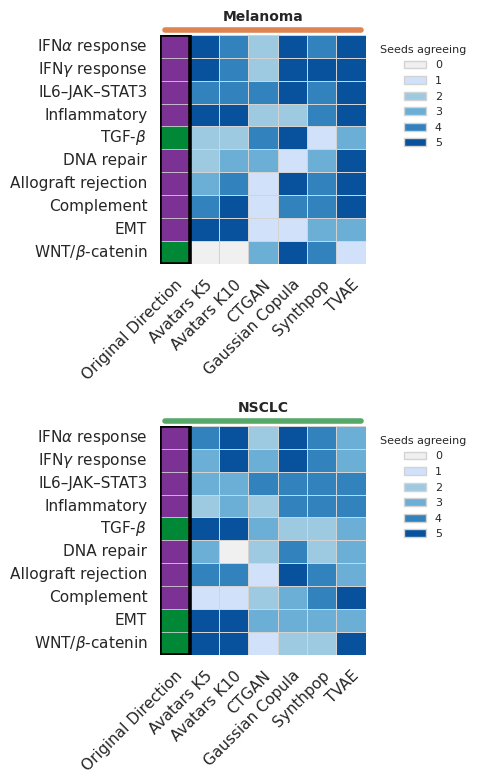

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path


# seeds to include (5 replicates)
seeds = [0, 1, 2, 3, 42]

terms = [
    'HALLMARK_INTERFERON_ALPHA_RESPONSE','HALLMARK_INTERFERON_GAMMA_RESPONSE',
    'HALLMARK_IL6_JAK_STAT3_SIGNALING','HALLMARK_INFLAMMATORY_RESPONSE',
    'HALLMARK_TGF_BETA_SIGNALING','HALLMARK_DNA_REPAIR','HALLMARK_ALLOGRAFT_REJECTION',
    'HALLMARK_COMPLEMENT', 'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION',
    'HALLMARK_WNT_BETA_CATENIN_SIGNALING'
]

# datasets mapping (short filename -> display name)
names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']
short_names = ['avatarsk5', 'avatarsk10', 'ctgan', 'gaussiancopula', 'synthpop', 'tvae']

def collect_method_seed_dfs(base_dir: Path, dataset_short: str, seeds: list, terms: list):
    dfs = []
    for s in seeds:
        p = base_dir / f"Seed_{s}" / f"GSEA_{dataset_short}_{s}.csv"
        if not p.exists():
            continue
        df = pd.read_csv(p)
        df = df[df['Term'].isin(terms)][['Term', 'NES']].copy()
        df['Seed'] = int(s)
        dfs.append(df)
    return dfs

def compute_count_matrix(origin_df: pd.DataFrame, method_seed_dfs: dict, terms: list, sign_eps: float = 1e-8):
    """
    Return DataFrame indexed by shortened terms, columns = ['Original Direction'] + names,
    values = integer count of seeds agreeing with Origin (0..5) or NaN if Origin missing/neutral or no non-neutral seeds.
    """
    origin_s = origin_df.set_index('Term')['NES'].astype(float)
    short_terms = [_shorten_hallmark_term(t) for t in terms]
    cols = ['Original Direction'] + names
    mat = pd.DataFrame(index=short_terms, columns=cols, dtype=float)

    def sign_val(x):
        if not np.isfinite(x):
            return 0
        if abs(x) <= sign_eps:
            return 0
        return 1 if x > 0 else -1

    for term, short_term in zip(terms, short_terms):
        # origin sign
        if term not in origin_s.index or pd.isna(origin_s.loc[term]):
            origin_sign = np.nan
        else:
            v0 = float(origin_s.loc[term])
            if abs(v0) <= sign_eps:
                origin_sign = 0.0
            else:
                origin_sign = 1 if v0 > 0 else -1

        # Original Direction column left as NaN (will be repainted)
        mat.loc[short_term, 'Original Direction'] = np.nan

        for ds_short, ds_display in zip(short_names, names):
            dfs = method_seed_dfs.get(ds_short, [])
            nes_vals = []
            for d in dfs:
                if term in d['Term'].values:
                    v = pd.to_numeric(d.loc[d['Term'] == term, 'NES'].values[0], errors='coerce')
                    if pd.notna(v):
                        nes_vals.append(float(v))
            if len(nes_vals) == 0:
                mat.loc[short_term, ds_display] = np.nan
                continue

            signs = [sign_val(x) for x in nes_vals]
            non_neutral = [s for s in signs if s != 0]

            if origin_sign is None or (isinstance(origin_sign, float) and np.isnan(origin_sign)) or origin_sign == 0:
                # origin missing or neutral -> can't compute meaningful agreement
                mat.loc[short_term, ds_display] = np.nan
                continue
            if len(non_neutral) == 0:
                mat.loc[short_term, ds_display] = np.nan
                continue

            count_agree = sum(1 for s in non_neutral if s == origin_sign)
            # Cap at 5 to fit palette (but normally <= len(seeds))
            count_agree = int(count_agree)
            mat.loc[short_term, ds_display] = count_agree

    return mat

# Paths for cancers (adjust to your layout)
base_dirs = {
    'Melanoma': Path('../Melanoma/NarrowUtility/GSEA/CRPR_PD'),
    'NSCLC': Path('../NSCLC/NarrowUtility/GSEA/CRPR_PD'),
}

count_matrices = {}
origin_dirs = {}

for cancer, base_dir in base_dirs.items():
    origin_path = base_dir / 'Seed_42' / 'GSEA_Origin.csv'
    if not origin_path.exists():
        print(f"Origin file for {cancer} not found at {origin_path}, skipping.")
        continue
    origin_df = pd.read_csv(origin_path)
    origin_df = origin_df[origin_df['Term'].isin(terms)][['Term', 'NES']].copy()

    method_seed_dfs = {}
    for short in short_names:
        dfs = collect_method_seed_dfs(base_dir, short, seeds, terms)
        method_seed_dfs[short] = dfs

    mat_counts = compute_count_matrix(origin_df=origin_df, method_seed_dfs=method_seed_dfs, terms=terms)
    count_matrices[cancer] = mat_counts

    # build origin direction series indexed by shortened terms
    origin_s = origin_df.set_index('Term')['NES'].astype(float)
    idx = [_shorten_hallmark_term(t) for t in terms]
    origin_dir = pd.Series(index=idx, dtype=float)
    for t, short_t in zip(terms, idx):
        if t not in origin_s.index or pd.isna(origin_s.loc[t]):
            origin_dir.loc[short_t] = np.nan
        else:
            v = float(origin_s.loc[t])
            if abs(v) <= 1e-8:
                origin_dir.loc[short_t] = 0.0
            else:
                origin_dir.loc[short_t] = 1.0 if v > 0 else -1.0
    origin_dirs[cancer] = origin_dir

# Plot discrete count heatmaps (0..5)
fig, axes = plot_agreement_count_heatmap_grid(
    count_matrices_by_cancer=count_matrices,
    origin_dirs_by_cancer=origin_dirs,
    cancers_order=list(count_matrices.keys()),
    figsize=(5, 4 * len(count_matrices)),  # adjust
    fontsize=9,
    hatch_missing=True,
    show=True,
)

fig.savefig("HeatmapAgreement_counts_combined_seeds.pdf", dpi=300, bbox_inches="tight", facecolor="white")